# EEE511 Assignment 1: Explore Activation Functions and MLP Input-Output Mappings

**Team:** Preston Garrett, Xin Yen Lim, Sam McDowell

**Team Number:** 1

**Date:** 9/8/2026

In [8]:
from dataclasses import dataclass


import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [9]:
x = np.linspace(-5, 5, 101)[:, None]


@dataclass
class MLPParams:
    w: np.ndarray
    b: np.ndarray
    v: np.ndarray
    c: float

## MLP Parameters

In [10]:
mlp_1 = MLPParams(
    w=np.array(
        [
            0.3352,
            -1.1440,
            0.8255,
            1.0346,
            -2.1461,
            -1.4324,
            0.1406,
            -0.3479,
            -0.0185,
            -0.9383,
            0.9673,
            0.8556,
            0.0726,
            1.2400,
            0.5143,
            -0.9452,
            0.4056,
            -1.0548,
            0.9663,
            -0.0549,
        ]
    ),
    b=np.array(
        [
            1.5485,
            -0.8728,
            2.8242,
            2.3587,
            1.6703,
            -1.8322,
            -0.1997,
            -2.7372,
            -2.0743,
            1.0983,
            1.4686,
            2.8051,
            -1.0450,
            -0.7772,
            -0.1827,
            -1.8632,
            -2.2205,
            -0.1458,
            -1.6385,
            1.0189,
        ]
    ),
    v=np.array(
        [
            0.2601,
            0.1901,
            -0.2329,
            0.0813,
            0.0408,
            0.0765,
            0.3050,
            0.0783,
            0.2376,
            0.0237,
            0.1012,
            0.2210,
            -0.5100,
            -0.1119,
            -0.1646,
            -0.2236,
            -0.0963,
            0.5232,
            -0.3030,
            0.3389,
        ]
    ),
    c=0.1500,
)

In [11]:
mlp_2 = MLPParams(
    w=np.array(
        [
            -1.2364,
            -0.4597,
            1.6099,
            0.2425,
            1.1503,
            0.7214,
            -0.7956,
            0.6774,
            -0.3957,
            -0.4030,
            0.1215,
            -1.9074,
            1.4902,
            -0.8389,
            1.2503,
            0.1704,
            1.9150,
            -0.8250,
            -0.3897,
            0.4222,
        ]
    ),
    b=np.array(
        [
            -1.8791,
            -2.3387,
            -0.0155,
            0.5791,
            -2.2096,
            -3.3957,
            -0.2021,
            1.5977,
            2.9302,
            0.8787,
            2.9199,
            2.5528,
            -1.9730,
            2.5629,
            1.6153,
            -1.5549,
            2.0793,
            2.5566,
            -1.4039,
            0.1893,
        ]
    ),
    v=np.array(
        [
            0.2767,
            -0.4794,
            0.5434,
            -0.0595,
            -0.2560,
            -0.2428,
            -0.0233,
            -0.1493,
            0.8702,
            -0.2729,
            0.0124,
            0.0107,
            0.0107,
            0.0210,
            -0.1830,
            -0.2217,
            -0.3276,
            -0.5655,
            0.0822,
            0.3741,
        ]
    ),
    c=-0.2500,
)

## Activation Functions

In [12]:
linear = lambda z: z
tanh = np.tanh
relu = lambda z: np.clip(z, a_min=0, a_max=None)
gelu = lambda z: z * norm.cdf(z)

## Plot

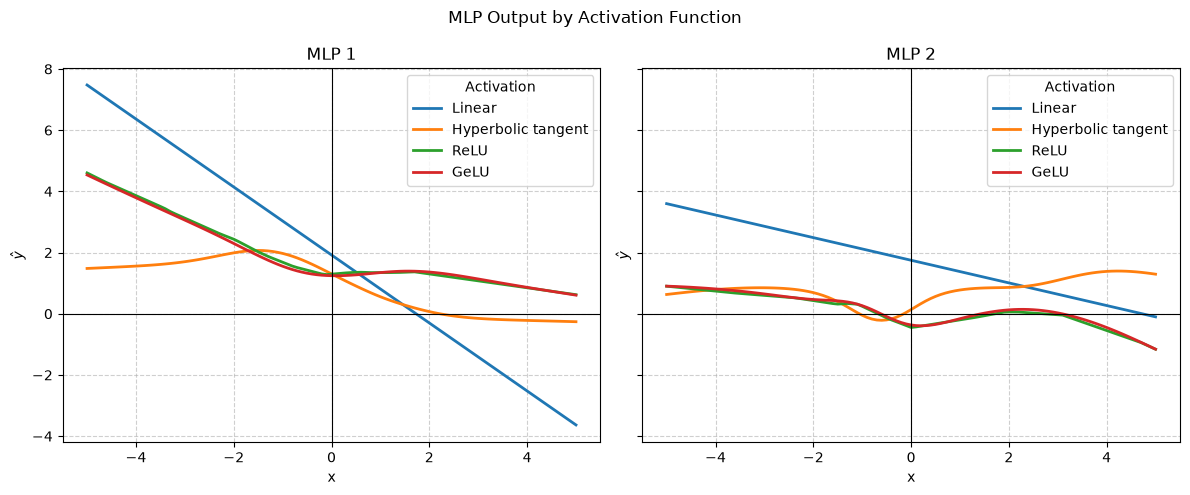

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, mlp, mlp_name in zip(axs, [mlp_1, mlp_2], ["MLP 1", "MLP 2"]):
    for activation, activation_name in [
        (linear, "Linear"),
        (tanh, "Hyperbolic tangent"),
        (relu, "ReLU"),
        (gelu, "GeLU"),
    ]:
        y_hat = np.sum(mlp.v * activation(mlp.w * x + mlp.b), axis=1) + mlp.c
        ax.plot(x, y_hat, label=activation_name, linewidth=2)

    ax.set_title(mlp_name)
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\hat{y}$")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.legend(title="Activation")

fig.suptitle("MLP Output by Activation Function")
fig.tight_layout()
plt.show()

## Reflection Questions

**1. Which activation function produces a purely linear input-output relationship and why?**

The "linear" activation produces a purely linear input-output relationship because every operation in the architecture, $\hat{y} = v^T\phi(Wx+b)+c$, is linear when $\phi(\cdot)$ is linear.

**2. Which activation functions produce nonlinear curves?**

All of the other activation functions (Hyperbolic tangent, ReLU, and GeLU) produce nonlinear curves because they are nonlinear and therefore introduce a nonlinearity into the architecture.

**3. Do you expect to see changes in the weights and biases change the curves, even when the
activation functions stay the same?**

I'm not 100% on what this question is asking, but I think it is asking whether changing the weights and biases will change the curve even with the same activation. If so, yes. Changing the weights and biases change what the activation function "sees", therefore changing the output. We see this in the differenece between the curves of MLP 1 and MLP 2.